In [1]:
import json
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

In [7]:
NUM_SAMPLES = 200
IMAGE_SIZE = 256
NUM_BLOCKS = 3
MIN_BLOCK = 40
MAX_BLOCK = 70

dataset_dir = Path("synthetic_dataset")
dataset_dir.mkdir(exist_ok=True)

def create_source_image():

    img = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)
    masks = []

    boxes = []

    for i in range(NUM_BLOCKS):

        size = random.randint(MIN_BLOCK, MAX_BLOCK)

        placed = False

        # try multiple times to place block without overlap
        for _ in range(50):

            x = random.randint(10, IMAGE_SIZE - size - 10)
            y = random.randint(10, IMAGE_SIZE - size - 10)

            new_box = (x, y, x+size, y+size)

            overlap = False
            for bx in boxes:
                if not (new_box[2] < bx[0] or new_box[0] > bx[2] or
                        new_box[3] < bx[1] or new_box[1] > bx[3]):
                    overlap = True
                    break

            if not overlap:
                boxes.append(new_box)
                placed = True
                break

        if not placed:
            continue

        mask = np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8)
        mask[y:y+size, x:x+size] = 1
        masks.append(mask)

        color = np.random.randint(100,255,size=3).tolist()
        img[y:y+size, x:x+size] = color

    return img, masks


def apply_rigid_transform(img, mask):

    ys, xs = np.where(mask == 1)

    cx = int(xs.mean())
    cy = int(ys.mean())

    angle = random.uniform(-30,30)
    tx = random.uniform(-25,25)
    ty = random.uniform(-25,25)

    M = cv2.getRotationMatrix2D((cx,cy), angle, 1)
    M[0,2] += tx
    M[1,2] += ty

    warped = cv2.warpAffine(img, M, (IMAGE_SIZE, IMAGE_SIZE))
    warped_mask = cv2.warpAffine(mask.astype(np.uint8)*255, M, (IMAGE_SIZE, IMAGE_SIZE))

    return warped, warped_mask, {"angle":angle,"tx":tx,"ty":ty}


for i in range(NUM_SAMPLES):

    sample_dir = dataset_dir / f"sample_{i:03d}"
    sample_dir.mkdir(exist_ok=True)

    source, masks = create_source_image()

    target = np.zeros_like(source)

    transforms = []

    for j, mask in enumerate(masks):

        warped, warped_mask, params = apply_rigid_transform(source, mask)

        target[warped_mask > 0] = warped[warped_mask > 0]

        cv2.imwrite(str(sample_dir / f"mask_{j}.png"), mask*255)

        transforms.append(params)

    cv2.imwrite(str(sample_dir / "source.png"), source)
    cv2.imwrite(str(sample_dir / "target.png"), target)

    with open(sample_dir / "transforms.json", "w") as f:
        json.dump(transforms, f)

print("Dataset generated at:", dataset_dir)

Dataset generated at: synthetic_dataset


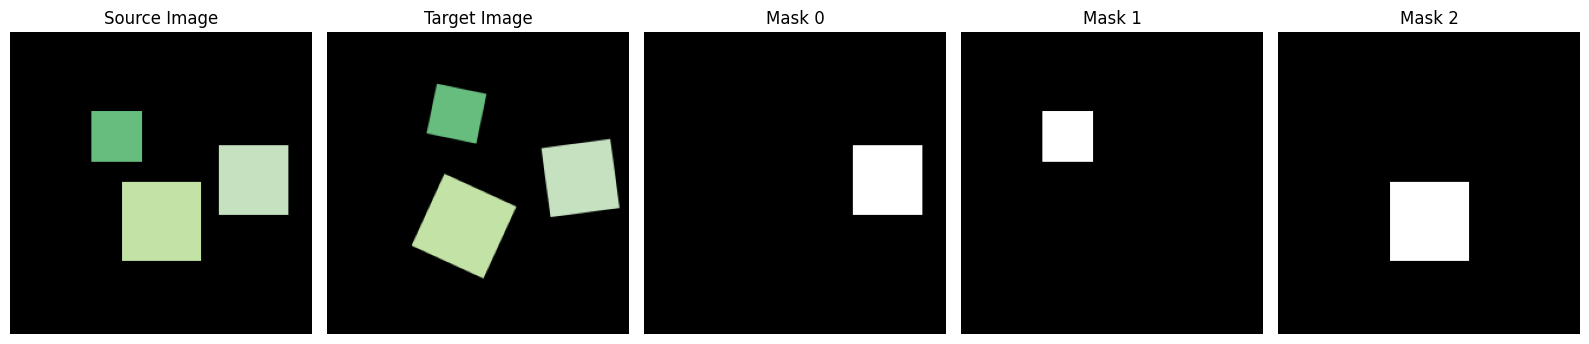

In [8]:
sample = dataset_dir / "sample_000"

# load images
source = cv2.imread(str(sample / "source.png"))
target = cv2.imread(str(sample / "target.png"))

source = cv2.cvtColor(source, cv2.COLOR_BGR2RGB)
target = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)

mask_paths = sorted(sample.glob("mask_*.png"))

masks = []
for mp in mask_paths:
    mask = cv2.imread(str(mp), 0)
    masks.append(mask)

# plotting
fig, axes = plt.subplots(1, 2 + len(masks), figsize=(16,4))

axes[0].imshow(source)
axes[0].set_title("Source Image")
axes[0].axis("off")

axes[1].imshow(target)
axes[1].set_title("Target Image")
axes[1].axis("off")

for i, mask in enumerate(masks):
    axes[2+i].imshow(mask, cmap="gray")
    axes[2+i].set_title(f"Mask {i}")
    axes[2+i].axis("off")

plt.tight_layout()
plt.show()

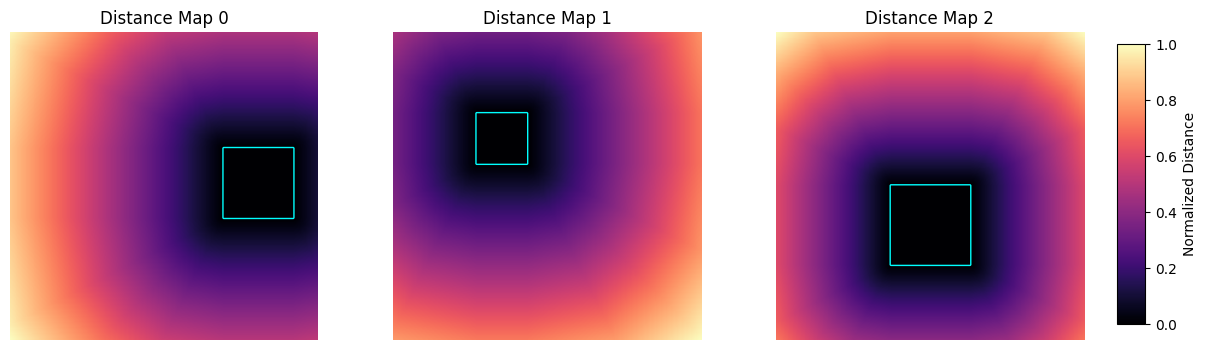

In [9]:
sample_path = dataset_dir / "sample_000"
mask_paths = sorted(sample_path.glob("mask_*.png"))

distance_maps = []
masks = []

for mp in mask_paths:

    mask = cv2.imread(str(mp), 0)
    mask = (mask > 0).astype(np.uint8)
    masks.append(mask)

    inv_mask = 1 - mask
    dist = cv2.distanceTransform(inv_mask, cv2.DIST_L2, 5)

    # normalize for visualization
    dist = dist / dist.max()

    distance_maps.append(dist)

# Create figure
fig, axes = plt.subplots(1, len(distance_maps), figsize=(14,4))

for i, (dist, mask) in enumerate(zip(distance_maps, masks)):

    im = axes[i].imshow(dist, cmap="magma", vmin=0, vmax=1)

    # overlay mask boundary
    axes[i].contour(mask, levels=[0.5], colors="cyan", linewidths=1)

    axes[i].set_title(f"Distance Map {i}")
    axes[i].axis("off")

# Add colorbar outside plots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Normalized Distance")

# Adjust layout so plots don't collide with colorbar
plt.subplots_adjust(right=0.9)

plt.show()

In [10]:
dataset_root = Path("synthetic_dataset")

samples = sorted(dataset_root.glob("sample_*"))

for sample in samples:

    mask_paths = sorted(sample.glob("mask_*.png"))

    # create metadata directory
    meta_dir = sample / "metadata" / "distance_map"
    meta_dir.mkdir(parents=True, exist_ok=True)

    for i, mp in enumerate(mask_paths):

        mask = cv2.imread(str(mp), 0)
        mask = (mask > 0).astype(np.uint8)

        # invert mask because distanceTransform measures distance to zero
        inv_mask = 1 - mask

        dist = cv2.distanceTransform(inv_mask, cv2.DIST_L2, 5)

        # save distance map
        np.save(meta_dir / f"dist_{i}.npy", dist)

print("Distance maps generated for all samples.")

Distance maps generated for all samples.


In [11]:
dataset_root = Path("synthetic_dataset")
samples = sorted(dataset_root.glob("sample_*"))

for sample in samples:

    mask_paths = sorted(sample.glob("mask_*.png"))
    dist_paths = sorted((sample / "metadata" / "distance_map").glob("dist_*.npy"))

    weight_dir = sample / "metadata" / "weight_map"
    weight_dir.mkdir(parents=True, exist_ok=True)

    masks = []
    dists = []

    for mp, dp in zip(mask_paths, dist_paths):
        mask = cv2.imread(str(mp), 0)
        mask = (mask > 0).astype(np.float32)
        masks.append(mask)

        dist = np.load(dp)
        dists.append(dist)

    masks = np.stack(masks)
    dists = np.stack(dists)

    # compute mass m_k (area of component)
    areas = masks.sum(axis=(1,2))
    masses = areas / areas.sum()

    # compute weights
    weights = masses[:,None,None] / (1 + dists**2)

    # normalize so sum_k w_k(x) = 1
    weights = weights / weights.sum(axis=0, keepdims=True)

    # save weights
    for i in range(weights.shape[0]):
        np.save(weight_dir / f"weight_{i}.npy", weights[i])

print("Weight fields generated for all samples.")

Weight fields generated for all samples.


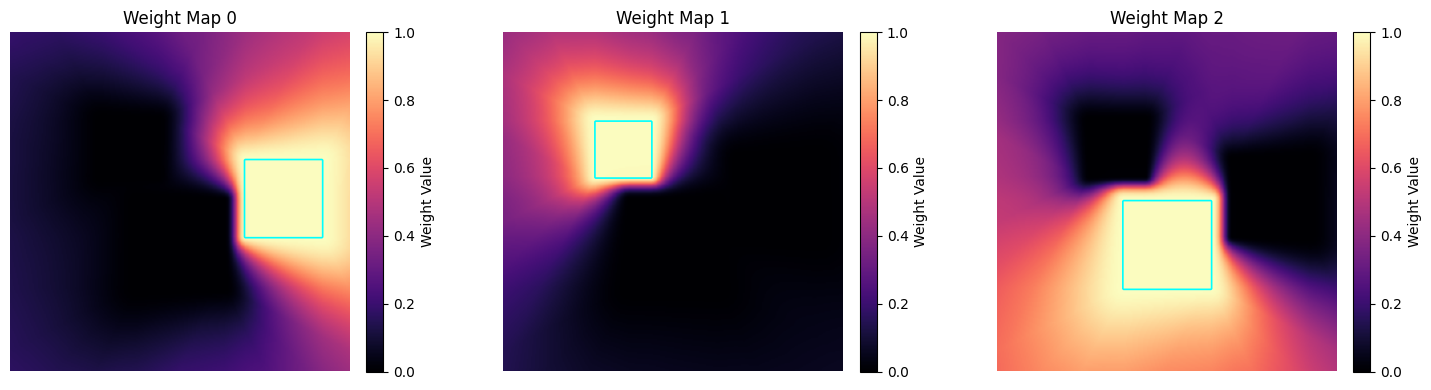

In [12]:
sample = dataset_root / "sample_000"

weight_paths = sorted((sample / "metadata" / "weight_map").glob("weight_*.npy"))
mask_paths = sorted(sample.glob("mask_*.png"))

plt.figure(figsize=(15,4))

for i, (wp, mp) in enumerate(zip(weight_paths, mask_paths)):

    w = np.load(wp)

    mask = cv2.imread(str(mp), 0)
    mask = (mask > 0).astype(np.uint8)

    plt.subplot(1, len(weight_paths), i+1)

    im = plt.imshow(w, cmap="magma", vmin=0, vmax=1)

    # overlay mask boundary
    plt.contour(mask, levels=[0.5], colors="cyan", linewidths=1.2)

    plt.title(f"Weight Map {i}")
    plt.axis("off")

    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label("Weight Value")

plt.tight_layout()
plt.show()

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
sample = dataset_root / "sample_000"

# load images
source = cv2.imread(str(sample / "source.png"))
target = cv2.imread(str(sample / "target.png"))

source = cv2.cvtColor(source, cv2.COLOR_BGR2RGB) / 255.0
target = cv2.cvtColor(target, cv2.COLOR_BGR2RGB) / 255.0

source = torch.tensor(source).permute(2,0,1).unsqueeze(0).float().to(device)
target = torch.tensor(target).permute(2,0,1).unsqueeze(0).float().to(device)

H, W = source.shape[-2:]

# load weight maps
weight_paths = sorted((sample / "metadata" / "weight_map").glob("weight_*.npy"))
weights = [np.load(w) for w in weight_paths]
weights = torch.tensor(np.stack(weights)).float().to(device)

K = weights.shape[0]

# normalize weights again for safety
weights = weights / weights.sum(dim=0, keepdim=True)

# parameters to learn
theta = torch.zeros(K, requires_grad=True, device=device)
tx = torch.zeros(K, requires_grad=True, device=device)
ty = torch.zeros(K, requires_grad=True, device=device)

optimizer = torch.optim.Adam([theta, tx, ty], lr=1e-2)

# coordinate grid
y, x = torch.meshgrid(
    torch.linspace(-1,1,H,device=device),
    torch.linspace(-1,1,W,device=device),
    indexing="ij"
)

coords = torch.stack([x,y], dim=-1)

def build_deformation():

    deformed = torch.zeros_like(coords)

    for k in range(K):

        cos = torch.cos(theta[k])
        sin = torch.sin(theta[k])

        R = torch.stack([
            torch.stack([cos, -sin]),
            torch.stack([sin, cos])
        ])

        transformed = coords @ R.T

        transformed[...,0] += tx[k]
        transformed[...,1] += ty[k]

        w = weights[k].unsqueeze(-1)

        deformed += w * transformed

    return deformed


# training loop
for step in range(400):

    optimizer.zero_grad()

    grid = build_deformation().unsqueeze(0)

    pred = F.grid_sample(source, grid, align_corners=True)

    loss = F.mse_loss(pred, target)

    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print(f"step {step} loss {loss.item():.5f}")

print("Optimization finished")

step 0 loss 0.04258
step 50 loss 0.00439
step 100 loss 0.00350
step 150 loss 0.00348
step 200 loss 0.00348
step 250 loss 0.00348
step 300 loss 0.00348
step 350 loss 0.00348
Optimization finished


In [14]:
def visualize_alignment_sample(sample_idx):

    sample = dataset_root / f"sample_{sample_idx:03d}"

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # load images
    source = cv2.imread(str(sample / "source.png"))
    target = cv2.imread(str(sample / "target.png"))

    source = cv2.cvtColor(source, cv2.COLOR_BGR2RGB) / 255.0
    target = cv2.cvtColor(target, cv2.COLOR_BGR2RGB) / 255.0

    source = torch.tensor(source).permute(2,0,1).unsqueeze(0).float().to(device)
    target = torch.tensor(target).permute(2,0,1).unsqueeze(0).float().to(device)

    H, W = source.shape[-2:]

    # load weights
    weight_paths = sorted((sample / "metadata" / "weight_map").glob("weight_*.npy"))
    weights = torch.tensor(np.stack([np.load(w) for w in weight_paths])).float().to(device)

    weights = weights / weights.sum(dim=0, keepdim=True)

    K = weights.shape[0]

    # parameters
    theta = torch.zeros(K, requires_grad=True, device=device)
    tx = torch.zeros(K, requires_grad=True, device=device)
    ty = torch.zeros(K, requires_grad=True, device=device)

    optimizer = torch.optim.Adam([theta, tx, ty], lr=1e-2)

    # coordinate grid
    y, x = torch.meshgrid(
        torch.linspace(-1,1,H,device=device),
        torch.linspace(-1,1,W,device=device),
        indexing="ij"
    )

    coords = torch.stack([x,y], dim=-1)

    def build_deformation():

        deformed = torch.zeros_like(coords)

        for k in range(K):

            cos = torch.cos(theta[k])
            sin = torch.sin(theta[k])

            R = torch.stack([
                torch.stack([cos, -sin]),
                torch.stack([sin, cos])
            ])

            transformed = coords @ R.T

            transformed[...,0] += tx[k]
            transformed[...,1] += ty[k]

            w = weights[k].unsqueeze(-1)

            deformed += w * transformed

        return deformed

    # optimization
    for step in range(300):

        optimizer.zero_grad()

        grid = build_deformation().unsqueeze(0)

        pred = F.grid_sample(source, grid, align_corners=True)

        loss = F.mse_loss(pred, target)

        loss.backward()
        optimizer.step()

    # visualize
    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(source[0].permute(1,2,0).cpu())
    plt.title("Source")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(target[0].permute(1,2,0).cpu())
    plt.title("Target")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred[0].permute(1,2,0).detach().cpu())
    plt.title("Aligned")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

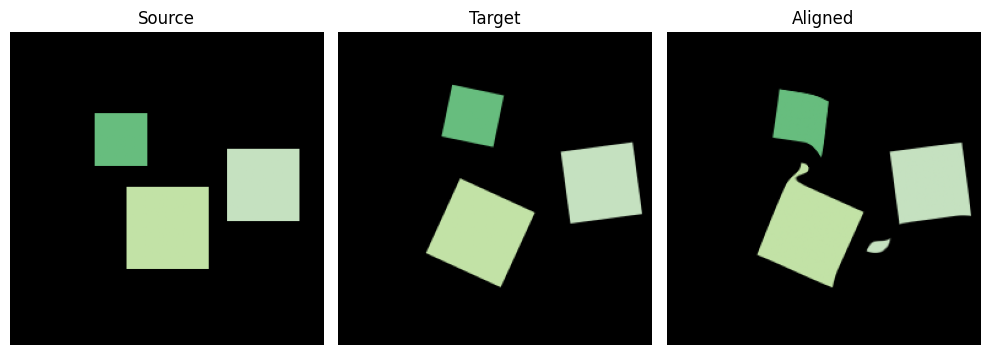

In [16]:
visualize_alignment_sample(0)

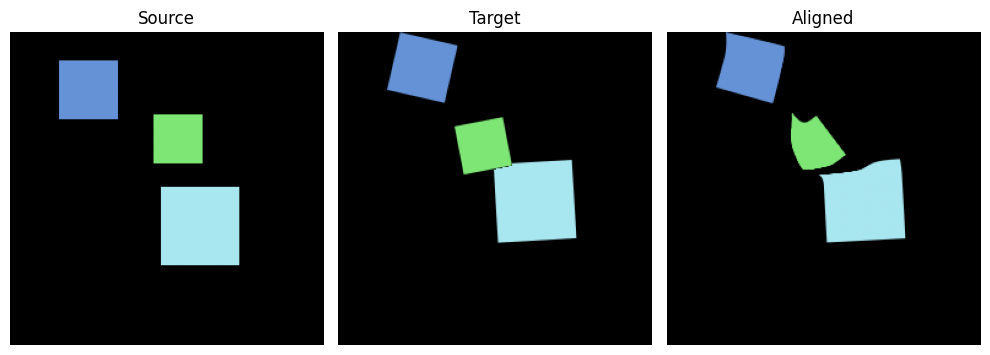

In [17]:
visualize_alignment_sample(2)

In [18]:
def load_sample(sample_idx):

    sample = dataset_root / f"sample_{sample_idx:03d}"

    source = cv2.imread(str(sample / "source.png"))
    target = cv2.imread(str(sample / "target.png"))

    source = cv2.cvtColor(source, cv2.COLOR_BGR2RGB) / 255.0
    target = cv2.cvtColor(target, cv2.COLOR_BGR2RGB) / 255.0

    source = torch.tensor(source).permute(2,0,1).unsqueeze(0).float()
    target = torch.tensor(target).permute(2,0,1).unsqueeze(0).float()

    weight_paths = sorted((sample / "metadata" / "weight_map").glob("weight_*.npy"))
    weights = torch.tensor(
        np.stack([np.load(w) for w in weight_paths])
    ).float()

    weights = weights / weights.sum(dim=0, keepdim=True)

    return source, target, weights

def exp_se2(omega, v):

    cos = torch.cos(omega)
    sin = torch.sin(omega)

    R = torch.stack([
        torch.stack([cos,-sin]),
        torch.stack([sin, cos])
    ])

    eps = 1e-6
    w = omega + eps

    A = sin / w
    B = (1 - cos) / w

    V = torch.stack([
        torch.stack([A,-B]),
        torch.stack([B, A])
    ])

    t = V @ v

    return R, t

def build_deformation(weights, omega, v, coords):

    H,W = weights.shape[1:]
    K = weights.shape[0]

    logT = torch.zeros(H,W,3)

    for k in range(K):

        logT[...,0] += weights[k] * omega[k]
        logT[...,1] += weights[k] * v[k,0]
        logT[...,2] += weights[k] * v[k,1]

    grid = torch.zeros(H,W,2)

    for i in range(H):
        for j in range(W):

            w = logT[i,j,0]
            v_xy = logT[i,j,1:]

            R,t = exp_se2(w, v_xy)

            p = coords[i,j]

            grid[i,j] = R @ p + t

    return grid

def train_polyrigid(source, target, weights, steps=600):

    device = source.device
    H,W = source.shape[-2:]
    K = weights.shape[0]

    # parameters in Lie algebra
    omega = torch.zeros(K,device=device,requires_grad=True)
    v = torch.zeros(K,2,device=device,requires_grad=True)

    optimizer = torch.optim.Adam([omega,v],lr=1e-2)

    # coordinate grid
    y,x = torch.meshgrid(
        torch.linspace(-1,1,H,device=device),
        torch.linspace(-1,1,W,device=device),
        indexing="ij"
    )

    coords = torch.stack([x,y],dim=-1).view(-1,2)   # (N,2)

    Wfield = weights.view(K,-1).T                    # (N,K)

    for step in range(steps):

        optimizer.zero_grad()

        # build log transforms (K,3)
        T = torch.cat([omega[:,None], v], dim=1)

        # interpolate log transforms per pixel
        logT = Wfield @ T                            # (N,3)

        w = logT[:,0]
        vx = logT[:,1]
        vy = logT[:,2]

        cos = torch.cos(w)
        sin = torch.sin(w)

        eps = 1e-6
        w_safe = w + eps

        A = sin / w_safe
        B = (1 - cos) / w_safe

        # compute translation
        tx = A * vx - B * vy
        ty = B * vx + A * vy

        # rotate points
        x = coords[:,0]
        y = coords[:,1]

        x_new = cos * x - sin * y + tx
        y_new = sin * x + cos * y + ty

        grid = torch.stack([x_new,y_new],dim=1).view(H,W,2)

        pred = F.grid_sample(source,grid.unsqueeze(0),align_corners=True)

        loss = F.mse_loss(pred,target)

        loss.backward()
        optimizer.step()

        if step % 100 == 0:
            print("step",step,"loss",loss.item())

    return omega.detach(), v.detach()

In [19]:
train_polyrigid(source, target, weights, steps=600)

step 0 loss 0.042581066489219666
step 100 loss 0.003526354907080531
step 200 loss 0.003511790418997407
step 300 loss 0.00350841018371284
step 400 loss 0.0035118910018354654
step 500 loss 0.0034731521736830473


(tensor([ 0.1357, -0.1981, -0.4254]),
 tensor([[-0.0696, -0.0740],
         [-0.0783,  0.1079],
         [-0.0191, -0.0499]]))

In [20]:
def visualize_alignment(sample_idx, omega, v):

    source, target, weights = load_sample(sample_idx)

    device = "cuda" if torch.cuda.is_available() else "cpu"

    source = source.to(device)
    target = target.to(device)
    weights = weights.to(device)

    H,W = source.shape[-2:]

    y,x = torch.meshgrid(
        torch.linspace(-1,1,H,device=device),
        torch.linspace(-1,1,W,device=device),
        indexing="ij"
    )

    coords = torch.stack([x,y],dim=-1)

    grid = build_deformation(weights, omega, v, coords)

    pred = F.grid_sample(source, grid.unsqueeze(0), align_corners=True)

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(source[0].permute(1,2,0).cpu())
    plt.title("Source")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(target[0].permute(1,2,0).cpu())
    plt.title("Target")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred[0].permute(1,2,0).detach().cpu())
    plt.title("Aligned")
    plt.axis("off")

    plt.show()

In [21]:
source, target, weights = load_sample(0)

omega, v = train_polyrigid(
    source,
    target,
    weights
)

step 0 loss 0.042581066489219666
step 100 loss 0.003526354907080531
step 200 loss 0.003511790418997407
step 300 loss 0.00350841018371284
step 400 loss 0.0035118910018354654
step 500 loss 0.0034731521736830473


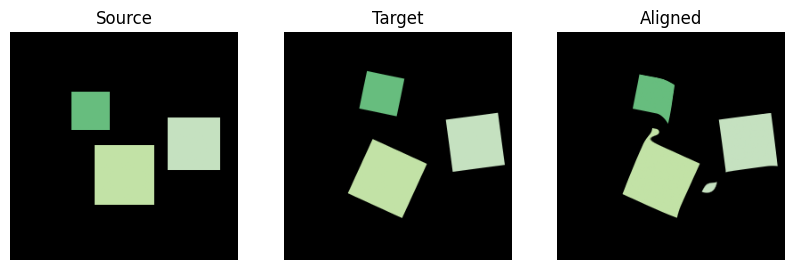

In [22]:
visualize_alignment(0, omega, v)